In [1]:
import pandas as pd
import numpy as np


df = pd.read_csv("/content/multiple_linear_regression_dataset.csv")

df.head()

,age,experience,income
0,25,1,30450
1,30,3,35670
2,47,2,31580
3,32,5,40130
4,43,10,47830


In [2]:
data = df.values

X = data[:, :-1]
y = data[:, -1]

y = y.reshape(-1, 1)


In [3]:
X = (X - X.mean(axis=0)) / X.std(axis=0)

In [4]:
X = np.hstack((np.ones((X.shape[0], 1)), X))

In [6]:
np.random.seed(42)

weights = np.random.randn(X.shape[1], 1)
learning_rate = 0.01
epochs = 1000

In [7]:
losses = []

for epoch in range(epochs):

    y_pred = X @ weights

    error = y - y_pred

    weights += learning_rate * X.T @ error / len(X)

    loss = np.mean(error ** 2)
    losses.append(loss)

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, MSE: {loss:.4f}")


Epoch 0, MSE: 1726999890.5904
Epoch 100, MSE: 234013225.8587
Epoch 200, MSE: 35232798.6674
Epoch 300, MSE: 7303790.8158
Epoch 400, MSE: 2890091.5759
Epoch 500, MSE: 1985281.1980
Epoch 600, MSE: 1718977.2484
Epoch 700, MSE: 1616198.4110
Epoch 800, MSE: 1571395.8651
Epoch 900, MSE: 1551041.4585


In [8]:

print("Final Weights:")
print(weights)

Final Weights:
[[40733.74141909]
 [ -867.31223941]
 [ 8590.55159557]]


In [9]:

y_pred = X @ weights

comparison = pd.DataFrame({
    "Actual": y.flatten(),
    "Predicted": y_pred.flatten()
})

comparison.head()


,Actual,Predicted
0,30450,30921.464188
1,35670,34751.731681
2,31580,31106.200429
3,40130,38848.214175
4,47830,48556.990407


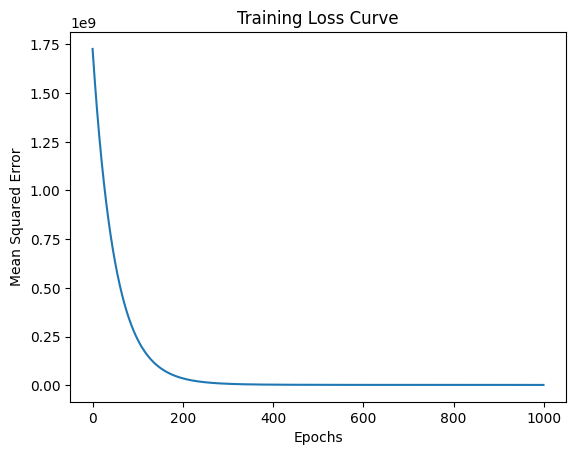

In [10]:

import matplotlib.pyplot as plt

plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error")
plt.title("Training Loss Curve")
plt.show()

In [11]:
mse = np.mean((y - y_pred) ** 2)
print("Mean Squared Error:", mse)

Mean Squared Error: 1541676.9879623733


In [12]:

from sklearn.metrics import r2_score

r2 = r2_score(y, y_pred)
print("R² Score:", r2)


R² Score: 0.9772172723397043
